# Unit 3 · Clustering & PCA

Course: **21CSC305P — Machine Learning**

## Aim
Find two groups of eruptions and reduce two measurements to one new feature.

## Assignment tasks
1. Implement K-means clustering, mixtures of Gaussians and Hierarchical clustering algorithm to categorize data.
2. Create a program to perform PCA.

## About this small dataset
Old Faithful is a geyser: a natural hot spring that sometimes shoots water into the air. This dataset has **299 eruptions and only two measurements**. Each row is one eruption, in the original recorded sequence.

**duration**: how long this eruption lasted, in minutes. **waiting**: how long people waited **before this eruption**, in minutes. There are no missing values, so we do not need to fill or remove them.

Source: [R MASS dataset documentation](https://stat.ethz.ch/R-manual/R-devel/library/MASS/html/geyser.html). Observations were collected August 1-15, 1985. Reference: Azzalini and Bowman (1990), *A look at some data on the Old Faithful geyser*. The supplied original CSV is from the Rdatasets mirror. We removed only its row-number column. Some night-time durations were recorded as 2, 3 or 4 minutes from short/medium/long descriptions.

Run the cells from top to bottom. Keep the `data` folder beside the `notebooks` folder. Learn each step by changing a value and rerunning the cell. These are small classroom demonstrations, not a complete prediction system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/geyser.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/geyser.csv')

print('Number of eruptions:', len(df))

Number of eruptions: 299


## Prepare the two features
Use duration and the following waiting time together. Standardization helps because duration is only a few minutes, while waiting is many more minutes. This unit explores the whole dataset; it is not a held-out prediction test.

In [2]:
from sklearn.preprocessing import StandardScaler

data = df.copy()
data['next_wait'] = data['waiting'].shift(-1)
data = data.dropna()
features = data[['duration', 'next_wait']]
scaled = StandardScaler().fit_transform(features)
display(features.head())

,duration,next_wait
0,4.016667,71.0
1,2.150000,57.0
2,4.000000,80.0
3,4.000000,75.0
4,4.000000,77.0


## Experiment 1 · Three ways to cluster
K-means assigns points to the nearest center. Gaussian mixtures use probabilities. Hierarchical clustering repeatedly joins nearby groups. We choose two groups to study short/long eruption patterns.

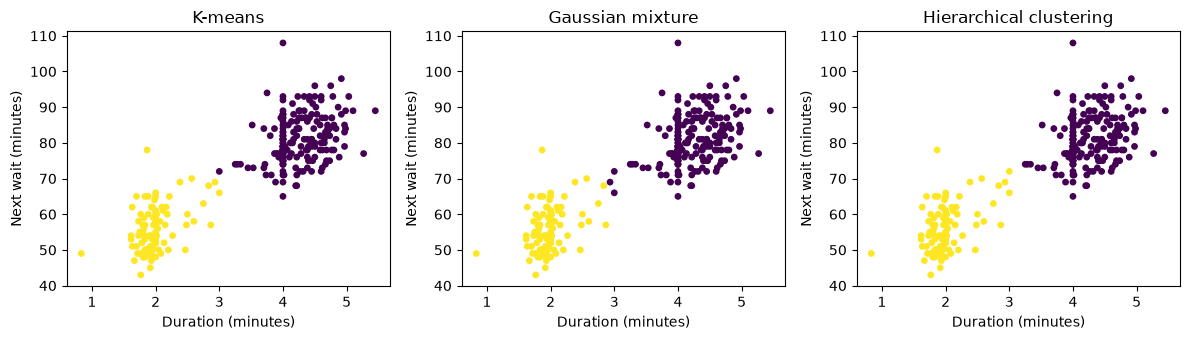

In [3]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled)
mixture = GaussianMixture(n_components=2, random_state=42)
mixture_labels = mixture.fit_predict(scaled)
hierarchy = AgglomerativeClustering(n_clusters=2)
hierarchy_labels = hierarchy.fit_predict(scaled)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].scatter(data['duration'], data['next_wait'], c=kmeans_labels, s=15)
axes[0].set_title('K-means')
axes[1].scatter(data['duration'], data['next_wait'], c=mixture_labels, s=15)
axes[1].set_title('Gaussian mixture')
axes[2].scatter(data['duration'], data['next_wait'], c=hierarchy_labels, s=15)
axes[2].set_title('Hierarchical clustering')
for ax in axes:
    ax.set_xlabel('Duration (minutes)')
    ax.set_ylabel('Next wait (minutes)')
plt.tight_layout()
plt.show()

## Experiment 2 · PCA
PCA creates new features from the original ones. Here we compress two standardized features into one principal component and report how much variation it keeps.

Original shape: (298, 2)
New shape: (298, 1)
Variance kept: 94.42 %


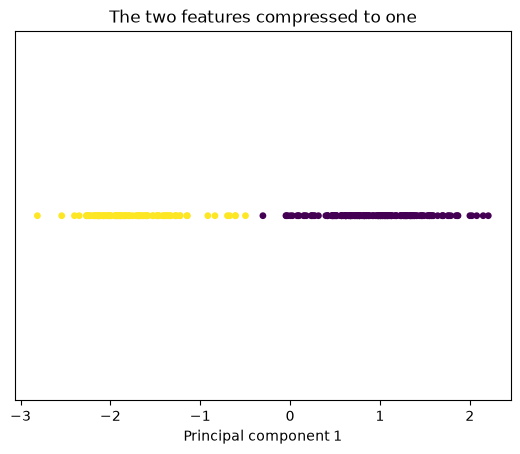

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
one_feature = pca.fit_transform(scaled)
print('Original shape:', scaled.shape)
print('New shape:', one_feature.shape)
print('Variance kept:', round(pca.explained_variance_ratio_[0] * 100, 2), '%')

plt.scatter(one_feature[:, 0], np.zeros(len(one_feature)), c=kmeans_labels, s=15)
plt.xlabel('Principal component 1')
plt.yticks([])
plt.title('The two features compressed to one')
plt.show()

## What to explain
Clustering does not need answer labels. Cluster 0 and cluster 1 are just names and can swap between methods. PCA reduces the number of features; it does not create a class label.

**Try:** Change `n_components=1` to `2` and compare the new shape.

**Viva:** Why scale the two columns? How is clustering different from classification?